In [1]:
import os, pickle, re
from pathlib import Path
from real_data import vendors, vendor_map, get_initial_state
from adoptionopinions_model import Simulation, Networks, Initial_state
from networks import complete
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import seaborn as sns
real_world_data = "browser-eu-monthly-201407-202605.csv"
n = 1000
model_path = f"best_model_browser/best_model_{n}.pkl"
import matplotlib.font_manager as fm
font_file = "../fonts/Arvo-Bold.ttf"
font = fm.FontProperties(fname=font_file)
plt.rcParams["font.family"] = font.get_name()
sns.set_theme(style="white", font_scale=1.6)
sns.despine()
%load_ext autoreload
%autoreload 2

<Figure size 640x480 with 0 Axes>

In [2]:
df = pd.read_csv(real_world_data)
df = df[vendors] / 100
#with open("sensitive_analysis.pkl", "rb") as fd:
#    betas = pickle.load(fd)
#g = sns.scatterplot(data=betas[0], color="grey", legend=False)
#plt.show()

best_model_browser/best_model_1000.pkl
3


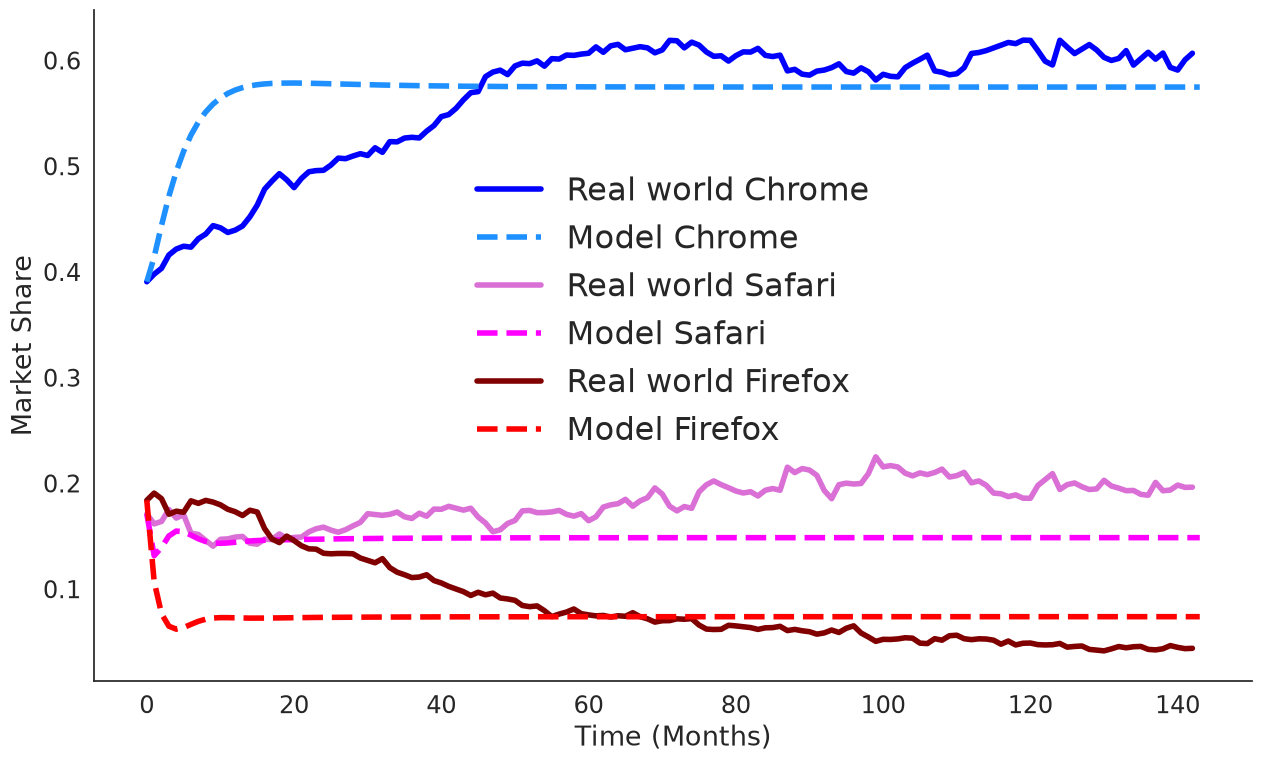

In [45]:
with open(model_path, "rb") as fd:
    print(model_path)
    SC = pickle.load(fd)

k = len(vendors)
print(k)
rows = len(df)
s, a = get_initial_state(n, df.iloc[0].tolist(), k)
IS = Initial_state(s, a, np.zeros((k,n)), SC.x0)
net = Networks(W=complete(n), V = complete(n))

sim = Simulation(
            simulation_constants = SC,
            initial_states = IS,
            net = net,
            window_size=2 * rows
            )

for _ in range(rows):
    sim()

# the shape of the object is: rows * k * n
states = sim.get_adoption_states()
market_share_prediction = [None] * k
for vendor in vendors:
    index = vendor_map[vendor]
    # market_share_prediction is a row long list of the mean of the k:th vendor.
    # rows * 1 * n -> rows * 1
    market_share_prediction[index] = np.array([state[index].mean() for state in states])

fig, ax = plt.subplots(figsize=(13, 8))

colors = [["blue", "dodgerblue"],["orchid", "magenta"], ["maroon", "red"]] 
for vendor in vendors:
    index = vendor_map[vendor]
    g = sns.lineplot(data=df[vendor], ax=ax, linewidth=4, legend=True, label=f"Real world {vendor}", color=colors[index][0])
    #g = sns.scatterplot(data=betas[index], color="grey", legend=False)
    g = sns.lineplot(linestyle="--", data=market_share_prediction[index], legend=True, ax=ax, linewidth=4, label=f"Model {vendor}", color=colors[index][1])
    


ax.legend(
    fontsize=23,
    loc="center",
    bbox_to_anchor=(0.5, 0.55),
    frameon=False
)
sns.despine()
g.set_ylabel("Market Share")
g.set_xlabel("Time (Months)")
plt.tight_layout()
plt.savefig(f"m.svg", format="svg", bbox_inches="tight", transparent=True)

plt.show()

In [ ]:
with open(model_path, "rb") as fd:
    print(model_path)
    SC = pickle.load(fd)

k = len(vendors)
print(k)
rows = len(df)
s, a = get_initial_state(n, df.iloc[0].tolist(), k)


tenth = np.array([0.1] * n)

lambd = np.vstack([SC.lambd, tenth])
xi = np.vstack([SC.xi, tenth])
beta = np.vstack([SC.beta, tenth])
gamma = np.vstack([SC.gamma, tenth])
delta = np.vstack([SC.delta, tenth])
x0 = np.vstack([SC.x0, tenth])

SC = Simulation_constants(SC.n, k, lambd, xi, beta, gamma, delta, x0)
IS = Initial_state(s, a, np.zeros((k,n)), x0)

net = Networks(W=complete(n), V = complete(n))

sim = Simulation(
            simulation_constants = SC,
            initial_states = IS,
            net = net,
            window_size=2 * rows
            )

for _ in range(rows):
    sim()

# the shape of the object is: rows * k * n
states = sim.get_adoption_states()
market_share_prediction = [None] * k
for vendor in vendors:
    index = vendor_map[vendor]
    # market_share_prediction is a row long list of the mean of the k:th vendor.
    # rows * 1 * n -> rows * 1
    market_share_prediction[index] = np.array([state[index].mean() for state in states])

fig, ax = plt.subplots(figsize=(12, 8))
o = 2
colors=["royalblue", "seagreen", "gold"]
for vendor in vendors:
    index = vendor_map[vendor]
    g = sns.lineplot(data=df[vendor], ax=ax, color="royalblue", linewidth=3, legend=False)
    g = sns.lineplot(linestyle="--", data=market_share_prediction[index], color="seagreen", legend=False, ax=ax, linewidth=3)




#g.legend(fontsize=14,    handlelength=2.5,    handleheight=1.5)
sns.despine()
g.set_ylabel("Market Share")
g.set_xlabel("Time (Months)")
plt.tight_layout()
plt.savefig(f"m.svg", format="svg", bbox_inches="tight", transparent=True)

plt.show()